tune from https://github.com/open-mmlab/mmdetection/blob/main/demo/MMDet_InstanceSeg_Tutorial.ipynb

# Instance Segmentation

In this tutorial, you will learn:
- the basic structure of Mask R-CNN.
- to perform inference with a MMDetection detector.
- to train a new instance segmentation model with a new dataset.

Let's start!

# インスタンスセグメンテーション
このチュートリアルでは、以下のことを学びます：

Mask R-CNNの基本構造
MMDetectionの検出器を使った推論の実施方法
新しいデータセットで新しいインスタンスセグメンテーションモデルを訓練する方法
さあ始めましょう！

<a href="https://colab.research.google.com/drive/11MqMCyF_V7Rkw6b9CCShGfNTP59OJ905?usp=sharing"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>

If you are running the tutorial files on the colab platform or a new virtual environment, please run the following code first to configure the runtime environment.

チュートリアルファイルをColabプラットフォームや新しい仮想環境で実行する場合は、まず以下のコードを実行してランタイム環境を構成してください。

```python
!pip install -U openmim
!mim install "mmengine>=0.7.0"
!mim install "mmcv>=2.0.0rc4"

# Install mmdetection
!rm -rf mmdetection
!git clone https://github.com/open-mmlab/mmdetection.git
%cd mmdetection

!pip install -e .
```

In [1]:
# Pytorchのインストール確認
import torch, torchvision  # Pytorchとtorchvisionをインポート
print("torch version:",torch.__version__, "cuda:",torch.cuda.is_available())  # バージョンとCUDA可否を表示
print("torch version:",torch.__version__, "cuda:",torch.cuda.is_available())
# MMDetectionのインストール確認
import mmdet  # MMDetectionをインポート
print("mmdetection:",mmdet.__version__)  # バージョンを表示
import mmdet
# mmcvのインストール確認
import mmcv  # mmcvをインポート
print("mmcv:",mmcv.__version__)  # バージョンを表示
# mmcvのインストール確認
# mmengineのインストール確認
import mmengine  # mmengineをインポート
print("mmengine:",mmengine.__version__)  # バージョンを表示

# mmengineのインストール確認
import mmengine
print("mmengine:",mmengine.__version__)


torch version: 2.1.2 cuda: True
torch version: 2.1.2 cuda: True
mmdetection: 3.3.0
mmcv: 2.1.0
mmengine: 0.10.7
mmengine: 0.10.7


## Perform Inference with An MMDetection Detector

## MMDetectionの検出器を使った推論の実施

### A two-stage detector

In this tutorial, we use Mask R-CNN, a simple two-stage detector as an example.

The high-level architecture of Mask R-CNN is shown in the following picture. More details can be found in the [paper](https://arxiv.org/abs/1703.06870).

<img src="https://user-images.githubusercontent.com/40661020/143967081-c2552bed-9af2-46c4-ae44-5b3b74e5679f.png" alt="mask rcnn" align="bottom" />

Mask R-CNN adds a mask branch based on the original Faster R-CNN. It also uses RoIAlign, a more precise version of RoIPooling for RoI feature extraction to improve the performance.

### two-stage検出器

このチュートリアルでは、シンプルなtwo-stage検出器であるMask R-CNNを例として使用します。

高レベルのMask R-CNNのアーキテクチャは、以下の図に示されています。詳細は[論文](https://arxiv.org/abs/1703.06870)をご覧ください。

<img src="https://user-images.githubusercontent.com/40661020/143967081-c2552bed-9af2-46c4-ae44-5b3b74e5679f.png" alt="mask rcnn" align="bottom" />

Mask R-CNNは、元のFaster R-CNNに基づいてマスクブランチを追加します。また、RoI特徴抽出のためにRoIPoolingのより正確なバージョンであるRoIAlignを使用して、パフォーマンスを向上させています。

In [2]:
!mim download mmdet --config mask-rcnn_r50-caffe_fpn_ms-poly-3x_coco --dest ./checkpoints  # Mask R-CNNの事前学習済みモデルをダウンロード

processing mask-rcnn_r50-caffe_fpn_ms-poly-3x_coco...
downloading ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.6/169.6 MiB 5.9 MB/s eta 0:00:0000:0100:02g ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/169.6 MiB ? eta -:--:--
downloading ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.6/169.6 MiB 5.9 MB/s eta 0:00:0000:01
Successfully downloaded mask_rcnn_r50_caffe_fpn_mstrain-poly_3x_coco_bbox_mAP-0.408__segm_mAP-0.37_20200504_163245-42aa3d00.pth to /workspaces/trial_mmdetection/demo/checkpoints
Successfully downloaded mask_rcnn_r50_caffe_fpn_mstrain-poly_3x_coco_bbox_mAP-0.408__segm_mAP-0.37_20200504_163245-42aa3d00.pth to /workspaces/trial_mmdetection/demo/checkpoints
Successfully dumped mask-rcnn_r50-caffe_fpn_ms-poly-3x_coco.py to /workspaces/trial_mmdetection/demo/checkpoints
Successfully dumped mask-rcnn_r50-caffe_fpn_ms-poly-3x_coco.py to /workspaces/trial_mmdetection/demo/checkpoints


In [11]:
import mmcv  # mmcvをインポート
import mmengine  # mmengineをインポート
from mmdet.apis import init_detector, inference_detector  # 検出器初期化・推論APIをインポート
from mmdet.utils import register_all_modules  # MMDetectionの全モジュール登録関数をインポート
# 設定ファイルを選択し、検出器を初期化
config_file = 'configs/mask_rcnn/mask-rcnn_r50-caffe_fpn_ms-poly-3x_coco.py'  # Mask R-CNNの設定ファイルパス
# ロードするチェックポイントファイルを設定
checkpoint_file = 'checkpoints/mask_rcnn_r50_caffe_fpn_mstrain-poly_3x_coco_bbox_mAP-0.408__segm_mAP-0.37_20200504_163245-42aa3d00.pth'  # 事前学習済みモデルのパス

# mmdet内のすべてのモジュールをレジストリに登録
register_all_modules()  # MMDetectionの全モジュールを登録

# 設定ファイルとチェックポイントファイルからモデルを構築
model = init_detector(config_file, checkpoint_file, device='cpu')  # 検出器モデルをCPUで初期化

Loads checkpoint by local backend from path: checkpoints/mask_rcnn_r50_caffe_fpn_mstrain-poly_3x_coco_bbox_mAP-0.408__segm_mAP-0.37_20200504_163245-42aa3d00.pth


From the printed model, we will find that the model does consist of the components that we described earlier. It uses ResNet as its CNN backbone, and has a RPN head and RoI Head.
The RoI Head includes box head and mask head. In addition, the model has a neural network module, named neck, directly after the CNN backbone. It is a [feature pyramid network (FPN)](https://arxiv.org/abs/1612.03144) for enhancing the multi-scale features.

印刷されたモデルから、モデルが前述したコンポーネントで構成されていることがわかります。CNNバックボーンとしてResNetを使用し、RPNヘッドとRoIヘッドを備えています。
RoIヘッドには、ボックスヘッドとマスクヘッドが含まれています。さらに、モデルには、CNNバックボーンの直後にネックと呼ばれるニューラルネットワークモジュールがあります。これは、マルチスケール特徴を強化するための[特徴ピラミッドネットワーク（FPN）](https://arxiv.org/abs/1612.03144)です。

### Inference with the detector

The model is successfully created and loaded, let's see how good it is. We use the high-level API `inference_detector` implemented in the MMDetection. This API is created to ease the inference process. The details of the codes can be found [here](https://github.com/open-mmlab/mmdetection/blob/master/mmdet/apis/inference.py#L15).

### 検出器を使った推論

モデルは正常に作成およびロードされました。どれほど優れているか見てみましょう。MMDetectionで実装されている高レベルのAPI `inference_detector`を使用します。このAPIは、推論プロセスを容易にするために作成されました。コードの詳細は[こちら](https://github.com/open-mmlab/mmdetection/blob/master/mmdet/apis/inference.py#L15)を参照してください。

In [12]:
# 検出器を使って推論を実行
image = mmcv.imread('demo/demo.jpg',channel_order='rgb')  # 画像をRGBで読み込み
result = inference_detector(model, image)  # モデルで推論を実行
print(result)  # 推論結果を表示

<DetDataSample(

    META INFORMATION
    ori_shape: (427, 640)
    img_shape: (800, 1199)
    img_id: 0
    batch_input_shape: (800, 1216)
    scale_factor: (1.8734375, 1.873536299765808)
    pad_shape: (800, 1216)
    img_path: None

    DATA FIELDS
    ignored_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            masks: BitmapMasks(num_masks=0, height=427, width=640)
            bboxes: tensor([], size=(0, 4))
            labels: tensor([], dtype=torch.int64)
        ) at 0x72f5651525c0>
    gt_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            masks: BitmapMasks(num_masks=0, height=427, width=640)
            bboxes: tensor([], size=(0, 4))
            labels: tensor([], dtype=torch.int64)
        ) at 0x72f5651525f0>
    pred_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            masks: tensor([[[False, False, False,

### Let's plot the result

### 結果をプロットしてみましょう

In [13]:
from mmdet.registry import VISUALIZERS  # 可視化モジュールのレジストリをインポート
# Visualizerを初期化（jupyter notebookでは一度だけ実行）
visualizer = VISUALIZERS.build(model.cfg.visualizer)  # モデル設定からVisualizerを構築
# dataset_metaはチェックポイントからロードされ、
# init_detectorでモデルに渡される
visualizer.dataset_meta = model.dataset_meta  # データセットメタ情報をVisualizerに設定

/opt/conda/lib/python3.10/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


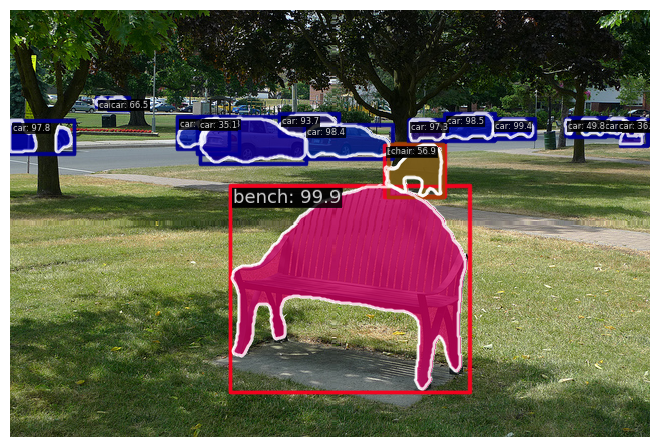

In [14]:
# 結果を表示
visualizer.add_datasample(
    'result',  # サンプル名
    image,  # 入力画像
    data_sample=result,  # 推論結果
    draw_gt = None,  # GT描画なし
    wait_time=0,  # 待機時間なし
)
visualizer.show()  # 画像を表示

## Train a Detector on A Customized Dataset

To train a new detector, there are usually three things to do:
1. Support a new dataset
2. Modify the config
3. Train a new detector

## カスタマイズされたデータセットで検出器を訓練する

新しい検出器を訓練するには、通常、次の3つのことを行います：
1. 新しいデータセットをサポートする
2. 設定を変更する
3. 新しい検出器を訓練する

### Support a new dataset

There are three ways to support a new dataset in MMDetection:
  1. Reorganize the dataset into a COCO format
  2. Reorganize the dataset into a middle format
  3. Implement a new dataset

We recommend the first two methods, as they are usually easier than the third.

In this tutorial, we give an example that converts the data into COCO format because MMDetection **only support evaluating mask AP of dataset in COCO format for now**. Other methods and more advanced usages can be found in the [doc](https://mmdetection.readthedocs.io/en/latest/advanced_guides/customize_dataset.html).

First, let's download the [the balloon dataset](https://github.com/matterport/Mask_RCNN/tree/master/samples/balloon).

### 新しいデータセットをサポートする

MMDetectionで新しいデータセットをサポートする方法は3つあります：
  1. データセットをCOCO形式に再編成する
  2. データセットを中間形式に再編成する
  3. 新しいデータセットを実装する

最初の2つの方法をお勧めします。通常、3番目の方法よりも簡単だからです。

このチュートリアルでは、データをCOCO形式に変換する例を示します。MMDetectionは**現在、COCO形式のデータセットのマスクAPの評価のみをサポートしている**ためです。他の方法やより高度な使用法については、[ドキュメント](https://mmdetection.readthedocs.io/en/latest/advanced_guides/customize_dataset.html)をご覧ください。

まず、[バルーンデータセット](https://github.com/matterport/Mask_RCNN/tree/master/samples/balloon)をダウンロードします。

In [15]:
# データをダウンロードして解凍
!wget -c https://github.com/matterport/Mask_RCNN/releases/download/v2.1/balloon_dataset.zip  # バルーンデータセットをダウンロード

--2025-09-24 04:53:46--  https://github.com/matterport/Mask_RCNN/releases/download/v2.1/balloon_dataset.zip
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/107595270/737339e2-2b83-11e8-856a-188034eb3468?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-09-24T05%3A37%3A01Z&rscd=attachment%3B+filename%3Dballoon_dataset.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-09-24T04%3A36%3A32Z&ske=2025-09-24T05%3A37%3A01Z&sks=b&skv=2018-11-09&sig=CXYL5yGS9lLCVlwqySfzdb%2FoEVaRZwn9c%2BK0RkJai8I%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc1ODY4OTkzMCwibm

In [16]:
!unzip balloon_dataset.zip -d ./ballondatasets/  # ダウンロードしたzipファイルを解凍

Archive:  balloon_dataset.zip
   creating: ./ballondatasets/balloon/
   creating: ./ballondatasets/balloon/train/
  inflating: ./ballondatasets/balloon/train/via_region_data.json  
   creating: ./ballondatasets/__MACOSX/
   creating: ./ballondatasets/__MACOSX/balloon/
   creating: ./ballondatasets/__MACOSX/balloon/train/
  inflating: ./ballondatasets/__MACOSX/balloon/train/._via_region_data.json  
  inflating: ./ballondatasets/balloon/train/53500107_d24b11b3c2_b.jpg     creating: ./ballondatasets/__MACOSX/
   creating: ./ballondatasets/__MACOSX/balloon/
   creating: ./ballondatasets/__MACOSX/balloon/train/
  inflating: ./ballondatasets/__MACOSX/balloon/train/._via_region_data.json  
  inflating: ./ballondatasets/balloon/train/53500107_d24b11b3c2_b.jpg  
  inflating: ./ballondatasets/__MACOSX/balloon/train/._53500107_d24b11b3c2_b.jpg  
  inflating: ./ballondatasets/balloon/train/120853323_d4788431b9_b.jpg  

  inflating: ./ballondatasets/__MACOSX/balloon/train/._53500107_d24b11b3c2_b.jp

# Check the directory structure of the tiny data

# 小さなデータのディレクトリ構造を確認する

# Install tree first in your terminal(linux)

# まず、ターミナル（Linux）でtreeをインストールしてください。

sudo apt-get -q install tree


In [17]:
!tree ballondatasets  # データセットディレクトリ構造を表示

/bin/bash: tree: command not found


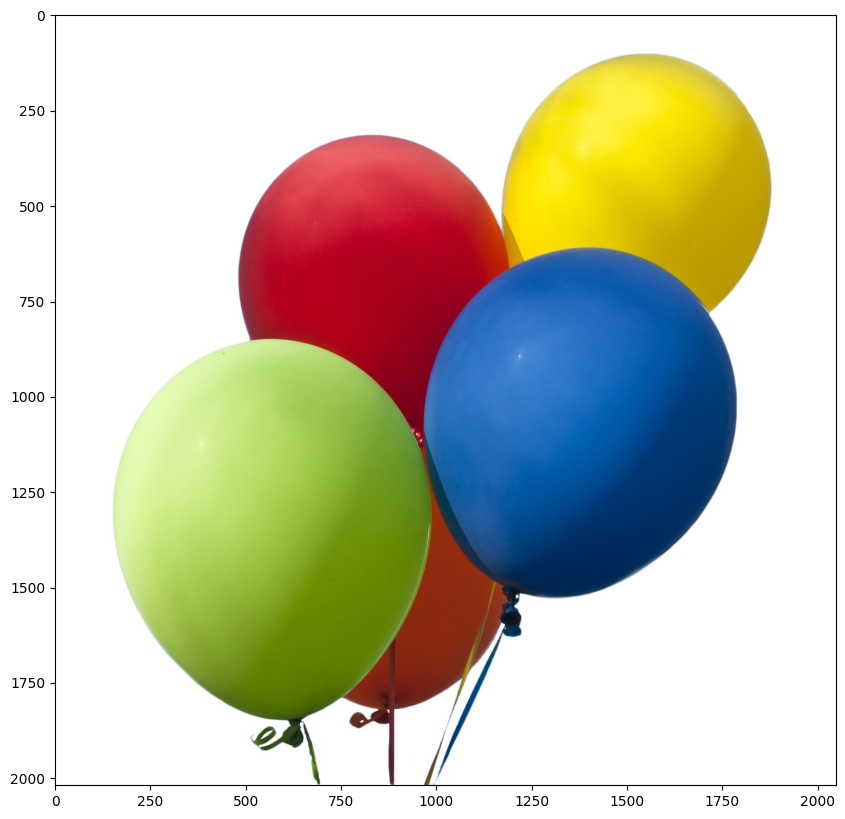

In [18]:
# データセット画像を表示してみる
import mmcv  # mmcvをインポート
import matplotlib.pyplot as plt  # matplotlibのpyplotをインポート

img = mmcv.imread('ballondatasets/balloon/train/10464445726_6f1e3bbe6a_k.jpg')  # 画像を読み込み
plt.figure(figsize=(15, 10))  # 画像表示サイズを指定
plt.imshow(mmcv.bgr2rgb(img))  # BGRからRGBに変換して表示
plt.show()  # 画像を表示

After downloading the data, we need to implement a function to convert the annotation format into the COCO format. Then we can use implemented `COCODataset` to load the data and perform training and evaluation.
Let's take a look at the annotation json file.

データをダウンロードした後、アノテーション形式をCOCO形式に変換する関数を実装する必要があります。次に、実装された`COCODataset`を使用してデータをロードし、訓練と評価を行うことができます。
アノテーションjsonファイルを見てみましょう。

In [19]:
# 単一画像のラベルを確認
import mmengine  # mmengineをインポート

annotation = mmengine.load('./ballondatasets/balloon/train/via_region_data.json')  # アノテーションJSONを読み込み

In [20]:
# annotationはdictであり、その値は以下のような形
annotation['34020010494_e5cb88e1c4_k.jpg1115004']  # 特定画像のアノテーション内容を表示

{'fileref': '',
 'size': 1115004,
 'filename': '34020010494_e5cb88e1c4_k.jpg',
 'base64_img_data': '',
 'file_attributes': {},
 'regions': {'0': {'shape_attributes': {'name': 'polygon',
    'all_points_x': [1020,
     1000,
     994,
     1003,
     1023,
     1050,
     1089,
     1134,
     1190,
     1265,
     1321,
     1361,
     1403,
     1428,
     1442,
     1445,
     1441,
     1427,
     1400,
     1361,
     1316,
     1269,
     1228,
     1198,
     1207,
     1210,
     1190,
     1177,
     1172,
     1174,
     1170,
     1153,
     1127,
     1104,
     1061,
     1032,
     1020],
    'all_points_y': [963,
     899,
     841,
     787,
     738,
     700,
     663,
     638,
     621,
     619,
     643,
     672,
     720,
     765,
     800,
     860,
     896,
     942,
     990,
     1035,
     1079,
     1112,
     1129,
     1134,
     1144,
     1153,
     1166,
     1166,
     1150,
     1136,
     1129,
     1122,
     1112,
     1084,
     1037,
     989,

According to the above observation, each single image has a corresponding annotation containing keys `filename` and `regions` that are necessary for training.
We need to read annotations of each image and convert them into COCO format as below:

上記の観察結果に基づき、各単一画像にはトレーニングに必要なキー `filename` と `regions` を含む対応するアノテーションが付与されています。
各画像のアノテーションを読み取り、以下のように COCO 形式に変換する必要があります：

```python
{
    "images": [image],
    "annotations": [annotation],
    "categories": [category]
}


image = {
    "id": int,
    "width": int,
    "height": int,
    "file_name": str,
}

annotation = {
    "id": int,
    "image_id": int,
    "category_id": int,
    "segmentation": RLE or [polygon],
    "area": float,
    "bbox": [x,y,width,height],
    "iscrowd": 0 or 1,
}

categories = [{
    "id": int,
    "name": str,
    "supercategory": str,
}]
```
**Note**: We only list the necessary keys for training, as shown above. For a full COCO format, please see [here](https://cocodataset.org/#format-data).

**注意**：上記のように、トレーニングに必要なキーのみをリストしています。完全なCOCO形式については、[こちら](https://cocodataset.org/#format-data)をご覧ください。

In [21]:
import os.path as osp  # os.pathをospとしてインポート

def convert_balloon_to_coco(ann_file, out_file, image_prefix):  # バルーンデータセットをCOCO形式に変換する関数
    data_infos = mmengine.load(ann_file)  # アノテーションJSONを読み込み

    annotations = []  # アノテーションリスト
    images = []  # 画像情報リスト
    obj_count = 0  # オブジェクトIDカウンタ
    for idx, v in enumerate(mmengine.track_iter_progress(list(data_infos.values()))):  # 進捗表示付きで各画像を処理
        filename = v['filename']  # ファイル名取得
        img_path = osp.join(image_prefix, filename)  # 画像パス作成
        height, width = mmcv.imread(img_path).shape[:2]  # 画像サイズ取得

        images.append(dict(  # COCO形式画像情報を追加
            id=idx,
            file_name=filename,
            height=height,
            width=width))

        bboxes = []  # バウンディングボックスリスト（未使用）
        labels = []  # ラベルリスト（未使用）
        masks = []  # マスクリスト（未使用）
        for _, obj in v['regions'].items():  # 各オブジェクト領域を処理
            assert not obj['region_attributes']  # 属性が空であることを確認
            obj = obj['shape_attributes']  # 形状属性のみ取得
            px = obj['all_points_x']  # ポリゴンX座標リスト
            py = obj['all_points_y']  # ポリゴンY座標リスト
            poly = [(x + 0.5, y + 0.5) for x, y in zip(px, py)]  # ポリゴン座標をfloat化
            poly = [p for x in poly for p in x]  # リストをフラット化

            x_min, y_min, x_max, y_max = (  # バウンディングボックス座標計算
                min(px), min(py), max(px), max(py))


            data_anno = dict(  # COCO形式アノテーション情報を作成
                image_id=idx,
                id=obj_count,
                category_id=0,
                bbox=[x_min, y_min, x_max - x_min, y_max - y_min],
                area=(x_max - x_min) * (y_max - y_min),
                segmentation=[poly],
                iscrowd=0)
            annotations.append(data_anno)  # アノテーションリストに追加
            obj_count += 1  # オブジェクトIDをインクリメント

    coco_format_json = dict(  # COCO形式全体JSONを作成
        info={"description": "Balloon dataset", "version": "1.0"},
        images=images,
        annotations=annotations,
        categories=[{'id':0, 'name': 'balloon'}])
    mmengine.dump(coco_format_json, out_file)  # JSONファイルとして保存

In [22]:
convert_balloon_to_coco(
    './ballondatasets/balloon/train/via_region_data.json',
    './ballondatasets/balloon/train/annotation_coco.json',
    './ballondatasets/balloon/train/')
convert_balloon_to_coco(
    './ballondatasets/balloon/val/via_region_data.json',
    './ballondatasets/balloon/val/annotation_coco.json',
    './ballondatasets/balloon/val/')

[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 61/61, 92.4 task/s, elapsed: 1s, ETA:     0s

[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 13/13, 85.9 task/s, elapsed: 0s, ETA:     0s                                                ] 0/13, elapsed: 0s, ETA:



Checking the label corresponding to the instance split ID after the data format conversion is complete

データ形式の変換が完了した後、インスタンス分割IDに対応するラベルを確認する

In [23]:
from pycocotools.coco import COCO  # COCO APIをインポート

# COCOアノテーションファイルのパス
annotation_file = './ballondatasets/balloon/train/annotation_coco.json'  # アノテーションファイルパス指定

# COCOオブジェクトを初期化
coco = COCO(annotation_file)  # COCO形式アノテーションをロード

# すべてのカテゴリタグと対応するカテゴリIDを取得
categories = coco.loadCats(coco.getCatIds())  # カテゴリ情報を取得
category_id_to_name = {cat['id']: cat['name'] for cat in categories}  # IDと名前の辞書作成

# すべてのカテゴリIDと対応するカテゴリ名を表示
for category_id, category_name in category_id_to_name.items():  # 各カテゴリを表示
    print(f"Category ID: {category_id}, Category Name: {category_name}")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Category ID: 0, Category Name: balloon
Done (t=0.00s)
creating index...
index created!
Category ID: 0, Category Name: balloon


### Modify the config

In the next step, we need to modify the config for the training.
To accelerate the process, we finetune a detector using a pre-trained detector.

### 設定を変更する

次のステップでは、トレーニングのために設定を変更する必要があります。
プロセスを加速するために、事前訓練された検出器を使用して検出器を微調整します。

In [24]:
from mmengine import Config  # MMEngineのConfigクラスをインポート
cfg = Config.fromfile('./configs/mask_rcnn/mask-rcnn_r50-caffe_fpn_ms-poly-1x_coco.py')  # 設定ファイルをロード

Given a config that trains a Mask R-CNN on COCO dataset, we need to modify some values to use it for training on the balloon dataset.

COCOデータセットでMask R-CNNを訓練する設定が与えられた場合、バルーンデータセットでの訓練に使用するためにいくつかの値を変更する必要があります。

In [25]:
from mmengine.runner import set_random_seed  # シード設定関数をインポート

# データセットのクラスと色を変更
cfg.metainfo = {  # クラス名とパレット色を設定
    'classes': ('balloon', ),
    'palette': [
        (220, 20, 60),
    ]
}

# データセットタイプとパスを変更
cfg.data_root = './ballondatasets/balloon'  # データルートを設定

cfg.train_dataloader.dataset.ann_file = 'train/annotation_coco.json'  # trainアノテーションファイル指定
cfg.train_dataloader.dataset.data_root = cfg.data_root  # trainデータルート指定
cfg.train_dataloader.dataset.data_prefix.img = 'train/'  # train画像ディレクトリ指定
cfg.train_dataloader.dataset.metainfo = cfg.metainfo  # trainメタ情報指定

cfg.val_dataloader.dataset.ann_file = 'val/annotation_coco.json'  # valアノテーションファイル指定
cfg.val_dataloader.dataset.data_root = cfg.data_root  # valデータルート指定
cfg.val_dataloader.dataset.data_prefix.img = 'val/'  # val画像ディレクトリ指定
cfg.val_dataloader.dataset.metainfo = cfg.metainfo  # valメタ情報指定

cfg.test_dataloader = cfg.val_dataloader  # テストデータローダをvalと同じに設定

# メトリック設定を変更
cfg.val_evaluator.ann_file = cfg.data_root+'/'+'val/annotation_coco.json'  # val評価用アノテーション指定
cfg.test_evaluator = cfg.val_evaluator  # テスト評価をvalと同じに設定

# box headとmask headのクラス数を変更
cfg.model.roi_head.bbox_head.num_classes = 1  # bbox headのクラス数を1に設定
cfg.model.roi_head.mask_head.num_classes = 1  # mask headのクラス数を1に設定

# より高い性能を得るために事前学習済みMask RCNNモデルを利用
cfg.load_from = 'checkpoints/mask_rcnn_r50_caffe_fpn_mstrain-poly_3x_coco_bbox_mAP-0.408__segm_mAP-0.37_20200504_163245-42aa3d00.pth'  # 事前学習済みモデルパス指定

# ファイルとログ保存用の作業ディレクトリを設定
cfg.work_dir = './tutorial_exps'  # 作業ディレクトリ指定


# 評価間隔を設定して評価回数を減らす
cfg.train_cfg.val_interval = 3  # 評価間隔を3エポックごとに設定
# チェックポイント保存間隔を設定してストレージコストを削減
cfg.default_hooks.checkpoint.interval = 3  # チェックポイント保存間隔を3エポックごとに設定

# 元の学習率(LR)は8-GPU用。1GPUなので8で割る
cfg.optim_wrapper.optimizer.lr = 0.02 / 8  # 学習率を調整
cfg.default_hooks.logger.interval = 10  # ログ出力間隔を10イテレーションごとに設定


# シードを設定して再現性を高める
# cfg.seed = 0  # シード値（コメントアウト）
set_random_seed(0, deterministic=False)  # シード値を設定

# tensorboardで学習過程を記録する設定も可能
cfg.visualizer.vis_backends.append({"type":'TensorboardVisBackend'})  # Tensorboardバックエンドを追加

#------------------------------------------------------
config=f'./configs/mask_rcnn/mask-rcnn_r50-caffe_fpn_ms-poly-3x_balloon.py'  # 新しい設定ファイルパス
with open(config, 'w') as f:  # 設定ファイルを書き出し
    f.write(cfg.pretty_text)  # 設定内容を保存

### Train a new detector

Finally, lets initialize the dataset and detector, then train a new detector!

### 新しい検出器を訓練する

最後に、データセットと検出器を初期化し、新しい検出器を訓練しましょう！

In [26]:
!CUDA_VISIBLE_DEVICES=-1 python tools/train.py {config}  # GPUを使わずに新しい設定で学習を開始

09/24 04:54:28 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.10.13 (main, Sep 11 2023, 13:44:35) [GCC 11.2.0]
    CUDA available: False
    MUSA available: False
    numpy_random_seed: 230779150
    GCC: gcc (Ubuntu 9.4.0-1ubuntu1~20.04.2) 9.4.0
    PyTorch: 2.1.2
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX512
  - Build settings: BLAS_INFO=mkl, BUILD_TYPE=Release, CUDA_VERSION=12.1, CUDNN_VERSION=8.9.2, CXX_COMPILER=/opt/rh/devtoolset-9/root/usr/bin/c++, CXX_FLAGS= -D_GLIBCXX_USE_CXX11_ABI=0 -fabi-version=11 -fvisibilit

### Understand the log
From the log, we can have a basic understanding on the training process and know how well the detector is trained.

First, since the dataset we are using is small, we loaded a Mask R-CNN model and finetune it for detection. Because the original Mask R-CNN is trained on COCO dataset that contains 80 classes but KITTI Tiny dataset only have 3 classes. Therefore, the last FC layers of the pre-trained Mask R-CNN for classification and regression have different weight shape and are not used. The pre-trained weights of mask prediction layer `mask_head.conv_logits` also does not matches the current model and is not used due to similar reason.

Third, after training, the detector is evaluated by the default COCO-style evaluation. The results show that the detector achieves 79.6 bbox AP and 81.5 mask AP on the val dataset, not bad!

 We can also check the tensorboard to see the curves.

### ログを理解する
ログから、トレーニングプロセスの基本的な理解を得て、検出器がどれほどよく訓練されているかを知ることができます。

まず、使用しているデータセットが小さいため、Mask R-CNNモデルをロードし、検出のために微調整しました。元のMask R-CNNは80クラスを含むCOCOデータセットで訓練されていますが、KITTI Tinyデータセットには3クラスしかありません。したがって、分類と回帰のために事前訓練されたMask R-CNNの最後のFC層は異なる重み形状を持ち、使用されていません。マスク予測層`mask_head.conv_logits`の事前訓練された重みも同様の理由で現在のモデルと一致せず、使用されていません。

第三に、トレーニング後、検出器はデフォルトのCOCOスタイルの評価によって評価されます。結果は、検出器がvalデータセットで79.6 bbox APと81.5マスクAPを達成したことを示しており、悪くありません！

また、tensorboardをチェックして曲線を見ることもできます。

In [27]:
%pip install tensorboard  -i https://mirrors.ustc.edu.cn/pypi/web/simple  # tensorboardをインストール

Looking in indexes: https://mirrors.ustc.edu.cn/pypi/web/simple
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [29]:
# # jupyter notebookでtensorboardをロード
# %load_ext tensorboard  # tensorboard拡張をロード

In [31]:
# # tensorboardで曲線を確認
# # <IPython.core.display.HTML object>が表示された場合は再度実行してください
# %tensorboard --logdir tutorial_exps/  # 学習ログディレクトリを指定してtensorboardを起動

## Test the Trained Detector

After finetuning the detector, let's visualize the prediction results!

## 訓練された検出器をテストする

検出器を微調整した後、予測結果を視覚化してみましょう！

In [32]:
import mmcv  # mmcvをインポート
from mmdet.apis import init_detector, inference_detector  # 検出器初期化・推論APIをインポート
img = mmcv.imread('./ballondatasets/balloon/train/7178882742_f090f3ce56_k.jpg',channel_order='rgb')  # テスト画像をRGBで読み込み
checkpoint_file = 'tutorial_exps/epoch_12.pth'  # 学習済みモデルのパス
model = init_detector(cfg, checkpoint_file, device='cpu')  # 学習済みモデルをCPUで初期化
new_result = inference_detector(model, img)  # 新しいモデルで推論を実行
print(new_result)  # 推論結果を表示

Loads checkpoint by local backend from path: tutorial_exps/epoch_12.pth
<DetDataSample(

    META INFORMATION
    ori_shape: (1360, 2048)
    img_shape: (800, 1205)
    img_id: 0
    batch_input_shape: (800, 1216)
    scale_factor: (0.58837890625, 0.5882352941176471)
    pad_shape: (800, 1216)
    img_path: None

    DATA FIELDS
    ignored_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            masks: BitmapMasks(num_masks=0, height=1360, width=2048)
            bboxes: tensor([], size=(0, 4))
            labels: tensor([], dtype=torch.int64)
        ) at 0x72f56662b0d0>
    gt_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            masks: BitmapMasks(num_masks=0, height=1360, width=2048)
            bboxes: tensor([], size=(0, 4))
            labels: tensor([], dtype=torch.int64)
        ) at 0x72f566628580>
    pred_instances: <InstanceData(
        
            META INFORMATION

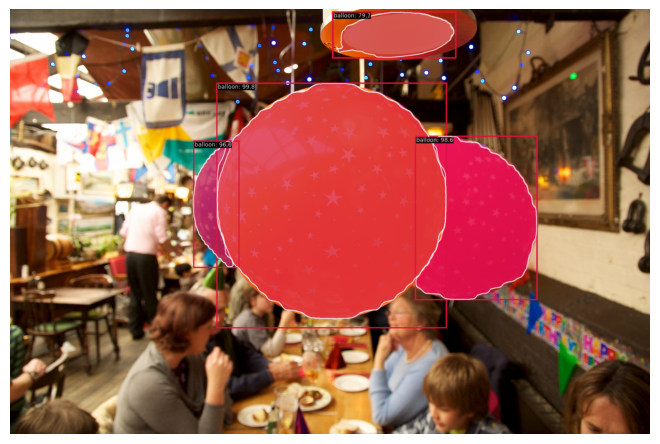

In [33]:
from mmengine.visualization import Visualizer  # Visualizerクラスをインポート
# Visualizerを取得
visualizer_now = Visualizer.get_current_instance()  # 現在のインスタンスを取得
# dataset_metaはチェックポイントからロードされ、
# init_detectorでモデルに渡される
visualizer_now.dataset_meta = model.dataset_meta  # データセットメタ情報を設定
# 結果を表示
visualizer_now.add_datasample(
    'new_result',
    img,
    data_sample=new_result,
    draw_gt=False,
    wait_time=0,
    out_file=None,
    pred_score_thr=0.5
)
visualizer_now.show()

## What to Do Next?

So far, we have learnt how to test and train Mask R-CNN. To further explore the segmentation task, you could do several other things as shown below:

- Try cascade methods, e.g., [Cascade Mask R-CNN](https://github.com/open-mmlab/mmdetection/tree/master/configs/cascade_rcnn) and [HTC](https://github.com/open-mmlab/mmdetection/tree/master/configs/htc) in [MMDetection model zoo](https://github.com/open-mmlab/mmdetection/blob/master/docs/en/model_zoo.md). They are powerful detectors that are ranked high in many benchmarks, e.g., COCO dataset.
- Try single-stage methods, e.g., [K-Net](https://github.com/ZwwWayne/K-Net) and [Dense-RepPoints](https://github.com/justimyhxu/Dense-RepPoints). These two algorithms are based on MMDetection. Box-free instance segmentation is a new trend in the instance segmentation community.
- Try semantic segmentation. Semantic segmentation is also a popular task with wide applications. You can explore [MMSegmentation](https://github.com/open-mmlab/mmsegmentation/); we also provide a [colab tutorial](https://github.com/open-mmlab/mmsegmentation/blob/master/demo/MMSegmentation_Tutorial.ipynb) for semantic segmentation using MMSegmentation.

## 次に何をするか？

これまで、Mask R-CNNのテストとトレーニング方法を学びました。セグメンテーションタスクをさらに探求するために、以下に示すようにいくつかの他のことを行うことができます：

- カスケードメソッドを試してみてください。例えば、[MMDetectionモデルズー](https://github.com/open-mmlab/mmdetection/blob/master/docs/en/model_zoo.md)の[Cascade Mask R-CNN](https://github.com/open-mmlab/mmdetection/tree/master/configs/cascade_rcnn)や[HTC](https://github.com/open-mmlab/mmdetection/tree/master/configs/htc)を試してみてください。これらは強力な検出器であり、多くのベンチマーク（例：COCOデータセット）で高く評価されています。
- シングルステージメソッドを試してみてください。例えば、[K-Net](https://github.com/ZwwWayne/K-Net)や[Dense-RepPoints](https://github.com/justimyhxu/Dense-RepPoints)を試してみてください。これらの2つのアルゴリズムはMMDetectionに基づいています。ボックスフリーインスタンスセグメンテーションは、インスタンスセグメンテーションコミュニティの新しいトレンドです。
- セマンティックセグメンテーションを試してみてください。セマンティックセグメンテーションも広範なアプリケーションを持つ人気のあるタスクです。[MMSegmentation](https://github.com/open-mmlab/mmsegmentation/)を探求できます。また、MMSegmentationを使用したセマンティックセグメンテーションのための[Colabチュートリアル](https://github.com/open-mmlab/mmsegmentation/blob/master/demo/MMSegmentation_Tutorial.ipynb)も提供しています。